# ESM-C layer sweep: vilip1

Sweeps HDBSCAN clustering quality across all 31 ESM-C hidden-state layers (`layer_0` = embedding output before any transformer block, `layer_30` = final layer, same one used in `esmc_embedding_analysis_vilip1.ipynb`) on the same filtered pool, using the same HDBSCAN params already tuned for that pool at the final layer -- held fixed across layers here so the sweep isolates the effect of layer depth, not re-tuned HDBSCAN parameters.

Goal: figure out whether embedding usefulness for clustering scales monotonically with depth or peaks somewhere in the middle, before spending time on the full UMAP/medoid/wet-lab-selection/structural-overlay pipeline on any particular layer.

Embeddings computed via `inference/embed_esmc.py --layers all` on Waluigi (one forward pass per batch; every hidden_states layer pooled from the same pass, so this cost nothing extra over the original final-layer-only run).

In [1]:
import os
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

## Filter to well-scored designs (same as final-layer notebook)

In [2]:
# vilip1 thresholds, same as esmc_embedding_analysis_vilip1.ipynb
# (no binding_confidence filter here -- vilip1's notebook doesn't use one).

# NOTE: this notebook lives at notebooks/bridget/esmc_embedding_analysis/ --
# three directories deep from the repo root, so data paths need ../../../.
MANIFEST_PATH = "../../../data/vilip1_full20k/manifest_with_ipsae.csv"
EMBEDDINGS_PATH = "../../../data/vilip1_full20k/embeddings_all_layers.npz"
# Sweep outputs land in a layer_sweep/ subfolder so they don't clobber the
# final-layer analysis files already in clustering/.
OUTPUT_DIR = "../../../data/vilip1_full20k/clustering/layer_sweep"
os.makedirs(OUTPUT_DIR, exist_ok=True)

manifest = pd.read_csv(MANIFEST_PATH)

IPTM_MIN = 0.7
IPSAE_MIN = 0.7
IPAE_MAX = 6.0

filtered_manifest = manifest[
    (manifest["iptm"] > IPTM_MIN)
    & (manifest["ipsae"] > IPSAE_MIN)
    & (manifest["ipae"] < IPAE_MAX)
].copy()

print(
    f"{len(filtered_manifest)}/{len(manifest)} designs pass " + f"iptm>{IPTM_MIN}, ipsae>{IPSAE_MIN}, ipae<{IPAE_MAX}"
)

filtered_ids = set(filtered_manifest["id"])


1130/20000 designs pass iptm>0.7, ipsae>0.7, ipae<6.0


## Load all-layer embeddings, restrict to filtered pool

In [3]:
npz = np.load(EMBEDDINGS_PATH, allow_pickle=True)
all_ids = npz["ids"]
keep_mask = np.array([eid in filtered_ids for eid in all_ids])
protein_names = all_ids[keep_mask].tolist()

layer_keys = sorted(
    [k for k in npz.files if k.startswith("layer_")],
    key=lambda k: int(k.split("_")[1]),
)
layer_indices = [int(k.split("_")[1]) for k in layer_keys]
print(f"Loaded {len(all_ids)} embeddings, kept {keep_mask.sum()} after filtering, {len(layer_keys)} layers ({layer_indices[0]}..{layer_indices[-1]})")

# L2-normalize each layer's filtered embeddings up front (HDBSCAN below runs
# euclidean distance, which on unit-norm vectors is equivalent to cosine --
# same convention as esmc_embedding_analysis_vilip1.ipynb).
X_by_layer = {
    idx: normalize(npz[f"layer_{idx}"][keep_mask], norm="l2", axis=1)
    for idx in layer_indices
}

Loaded 20000 embeddings, kept 1130 after filtering, 31 layers (0..30)


## Sweep HDBSCAN across every layer

In [4]:
MIN_CLUSTER_SIZE = 4
MIN_SAMPLES = 3

sweep_rows = []
for idx in layer_indices:
    X = X_by_layer[idx]
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        metric="euclidean",
        prediction_data=True,
    )
    labels = clusterer.fit_predict(X)

    n_total = len(labels)
    n_noise = int(np.sum(labels == -1))
    unique_clusters = set(labels) - {-1}
    n_clusters = len(unique_clusters)

    non_noise = labels != -1
    if n_clusters >= 2 and non_noise.sum() >= 2:
        sil = silhouette_score(X[non_noise], labels[non_noise], metric="cosine")
    else:
        sil = float("nan")

    sweep_rows.append({
        "layer": idx,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_frac": n_noise / n_total,
        "silhouette": sil,
    })
    print(f"layer {idx:>2}: clusters={n_clusters:>3}  noise={n_noise:>5}/{n_total} ({n_noise/n_total:.1%})  silhouette={sil:.4f}")

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(f"{OUTPUT_DIR}/layer_sweep_summary.csv", index=False)
print(f"\nSaved {OUTPUT_DIR}/layer_sweep_summary.csv")

layer  0: clusters=  2  noise=  996/1130 (88.1%)  silhouette=0.2658
layer  1: clusters=  3  noise=  907/1130 (80.3%)  silhouette=0.0506
layer  2: clusters=  2  noise= 1036/1130 (91.7%)  silhouette=0.0529
layer  3: clusters=  3  noise= 1052/1130 (93.1%)  silhouette=0.1171
layer  4: clusters=  2  noise= 1048/1130 (92.7%)  silhouette=0.0612
layer  5: clusters=  2  noise= 1070/1130 (94.7%)  silhouette=0.1173
layer  6: clusters=  2  noise=  300/1130 (26.5%)  silhouette=0.3055
layer  7: clusters=  2  noise=  856/1130 (75.8%)  silhouette=0.4171
layer  8: clusters=  2  noise=  253/1130 (22.4%)  silhouette=0.4125
layer  9: clusters=  4  noise=  605/1130 (53.5%)  silhouette=0.1038
layer 10: clusters=  2  noise=  195/1130 (17.3%)  silhouette=0.2404
layer 11: clusters=  2  noise=  169/1130 (15.0%)  silhouette=0.2864
layer 12: clusters=  2  noise=  121/1130 (10.7%)  silhouette=0.3201
layer 13: clusters=  2  noise=   80/1130 (7.1%)  silhouette=0.4033
layer 14: clusters=  2  noise=   86/1130 (7.6%)  

## Plot clustering quality vs. layer depth

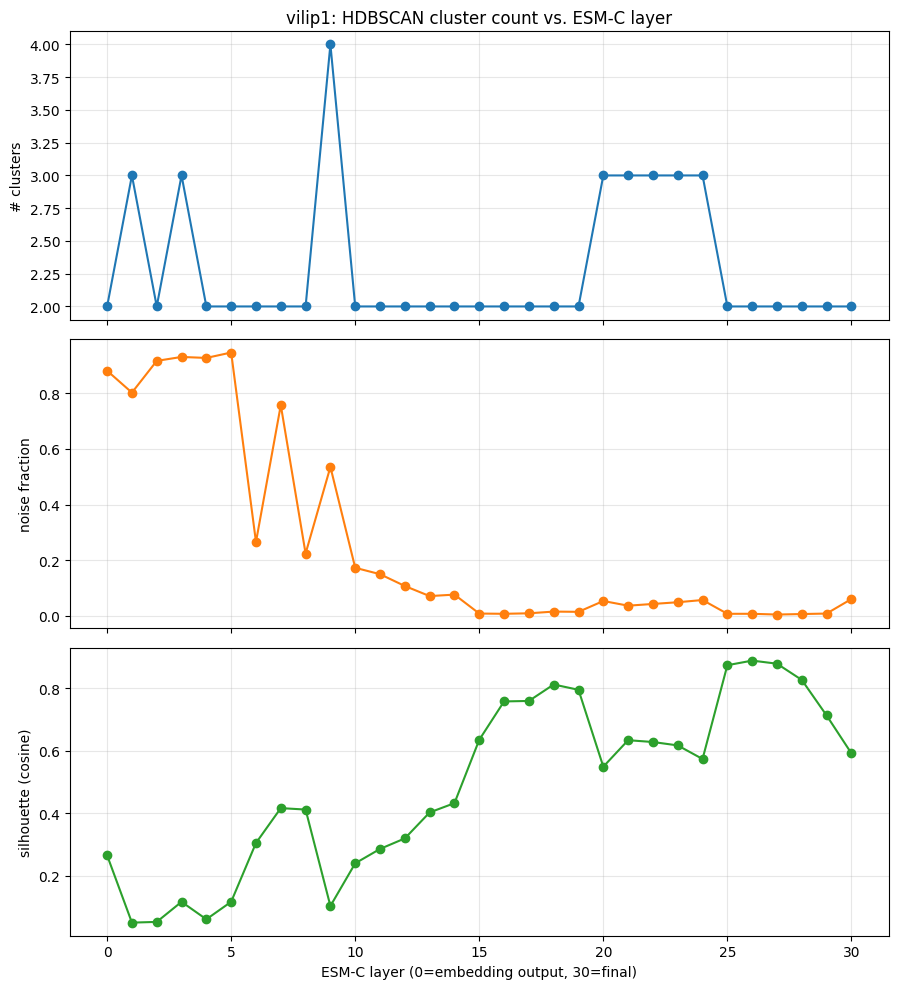

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(sweep_df["layer"], sweep_df["n_clusters"], marker="o")
axes[0].set_ylabel("# clusters")
axes[0].set_title("vilip1: HDBSCAN cluster count vs. ESM-C layer")

axes[1].plot(sweep_df["layer"], sweep_df["noise_frac"], marker="o", color="tab:orange")
axes[1].set_ylabel("noise fraction")

axes[2].plot(sweep_df["layer"], sweep_df["silhouette"], marker="o", color="tab:green")
axes[2].set_ylabel("silhouette (cosine)")
axes[2].set_xlabel("ESM-C layer (0=embedding output, 30=final)")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/layer_sweep.png", dpi=200)
plt.show()

## Candidate layers for the full deep-dive pipeline

In [6]:
# Ranks layers by silhouette among those that actually found >=2 clusters
# without collapsing to mostly noise (noise_frac < 0.5) -- a layer that puts
# everything in one cluster or calls everything noise isn't a useful
# clustering, whatever its silhouette says.
candidates = sweep_df[
    (sweep_df["n_clusters"] >= 2) & (sweep_df["noise_frac"] < 0.5)
].sort_values("silhouette", ascending=False)

print("Top candidate layers by silhouette (n_clusters>=2, noise<50%):")
print(candidates.head(10).to_string(index=False))

print("\nFinal layer (30) for reference:")
print(sweep_df[sweep_df["layer"] == 30].to_string(index=False))

Top candidate layers by silhouette (n_clusters>=2, noise<50%):
 layer  n_clusters  n_noise  noise_frac  silhouette
    26           2        8    0.007080    0.889297
    27           2        5    0.004425    0.879395
    25           2        8    0.007080    0.874533
    28           2        7    0.006195    0.827419
    18           2       17    0.015044    0.812796
    19           2       16    0.014159    0.795821
    17           2       10    0.008850    0.760137
    16           2        8    0.007080    0.758612
    29           2        9    0.007965    0.713698
    15           2        9    0.007965    0.635810

Final layer (30) for reference:
 layer  n_clusters  n_noise  noise_frac  silhouette
    30           2       68    0.060177    0.592512
